In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [2]:
obs_path = "../data/processed/ethiopia_fi_unified_data_enriched.csv"
impact_path = "../data/processed/impact_links_enriched.csv"

data = pd.read_csv(obs_path)
impact = pd.read_csv(impact_path)

data.head()


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN


In [3]:
data['observation_date'] = pd.to_datetime(
    data['observation_date'], errors='coerce'
)

data['year'] = data['observation_date'].dt.year


In [4]:
impact.info()
impact.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   record_id            14 non-null     object 
 1   parent_id            15 non-null     object 
 2   record_type          14 non-null     object 
 3   category             0 non-null      float64
 4   pillar               15 non-null     object 
 5   indicator            14 non-null     object 
 6   indicator_code       0 non-null      float64
 7   indicator_direction  0 non-null      float64
 8   value_numeric        12 non-null     float64
 9   value_text           0 non-null      float64
 10  value_type           14 non-null     object 
 11  unit                 14 non-null     object 
 12  observation_date     14 non-null     object 
 13  period_start         0 non-null      float64
 14  period_end           0 non-null      float64
 15  fiscal_year          0 non-null      float

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,...,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,...,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,...,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,...,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,...,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices


In [6]:
# Identify correct event ID column
events = data[data['record_type'] == 'event']

events[['record_id', 'indicator', 'observation_date']].head()


,record_id,indicator,observation_date
33,EVT_0001,Telebirr Launch,2021-05-17
34,EVT_0002,Safaricom Ethiopia Commercial Launch,2022-08-01
35,EVT_0003,M-Pesa Ethiopia Launch,2023-08-01
36,EVT_0004,Fayda Digital ID Program Rollout,2024-01-01
37,EVT_0005,Foreign Exchange Liberalization,2024-07-29


In [7]:
impact_full = impact.merge(
    events[['record_id', 'indicator', 'observation_date']],
    left_on='parent_id',
    right_on='record_id',
    how='left'
)

impact_full.head()


,record_id_x,parent_id,record_type,category,pillar,indicator_x,indicator_code,indicator_direction,value_numeric,value_text,...,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,record_id_y,indicator_y,observation_date_y
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,...,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years,EVT_0001,Telebirr Launch,2021-05-17
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,...,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition,EVT_0001,Telebirr Launch,2021-05-17
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,...,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel,EVT_0001,Telebirr Launch,2021-05-17
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,...,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition,EVT_0002,Safaricom Ethiopia Commercial Launch,2022-08-01
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,...,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices,EVT_0002,Safaricom Ethiopia Commercial Launch,2022-08-01


In [9]:
import pandas as pd

df = pd.read_csv("../data/processed/ethiopia_fi_unified_data_enriched.csv")

df.columns.tolist()


['record_id',
 'record_type',
 'category',
 'pillar',
 'indicator',
 'indicator_code',
 'indicator_direction',
 'value_numeric',
 'value_text',
 'value_type',
 'unit',
 'observation_date',
 'period_start',
 'period_end',
 'fiscal_year',
 'gender',
 'location',
 'region',
 'source_name',
 'source_type',
 'source_url',
 'confidence',
 'related_indicator',
 'relationship_type',
 'impact_direction',
 'impact_magnitude',
 'impact_estimate',
 'lag_months',
 'evidence_basis',
 'comparable_country',
 'collected_by',
 'collection_date',
 'original_text',
 'notes']

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/ethiopia_fi_unified_data_enriched.csv")

df.head()



,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load enriched data from Task 1
df = pd.read_csv("../data/processed/ethiopia_fi_unified_data_enriched.csv")

print("Data loaded successfully")
df.head()


Data loaded successfully


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN


In [14]:
print("Columns in dataset:")
for col in df.columns:
    print(col)


Columns in dataset:
record_id
record_type
category
pillar
indicator
indicator_code
indicator_direction
value_numeric
value_text
value_type
unit
observation_date
period_start
period_end
fiscal_year
gender
location
region
source_name
source_type
source_url
confidence
related_indicator
relationship_type
impact_direction
impact_magnitude
impact_estimate
lag_months
evidence_basis
comparable_country
collected_by
collection_date
original_text
notes


In [15]:
# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns


Index(['record_id', 'record_type', 'category', 'pillar', 'indicator',
       'indicator_code', 'indicator_direction', 'value_numeric', 'value_text',
       'value_type', 'unit', 'observation_date', 'period_start', 'period_end',
       'fiscal_year', 'gender', 'location', 'region', 'source_name',
       'source_type', 'source_url', 'confidence', 'related_indicator',
       'relationship_type', 'impact_direction', 'impact_magnitude',
       'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country',
       'collected_by', 'collection_date', 'original_text', 'notes'],
      dtype='object')

In [16]:
# Find numeric columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
numeric_cols

value_col = numeric_cols[0]
print("Using value column:", value_col)


Using value column: value_numeric


In [18]:
# Try to find a date-like column
date_candidates = [c for c in df.columns if "date" in c or "year" in c]
date_candidates

date_col = date_candidates[0]
print("Using date column:", date_col)

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df["year"] = df[date_col].dt.year


Using date column: observation_date


In [19]:
# Create event flag using text-based indicators
text_cols = df.select_dtypes(include="object").columns

df["event"] = 0

for col in text_cols:
    df.loc[
        df[col].str.contains("conflict|shock|drought|crisis", case=False, na=False),
        "event"
    ] = 1

df["event"].value_counts()


event
0    45
Name: count, dtype: int64

In [20]:
impact_summary = (
    df.groupby("event")[value_col]
    .mean()
    .reset_index()
)

impact_summary


,event,value_numeric
0,0,9.159691e+10


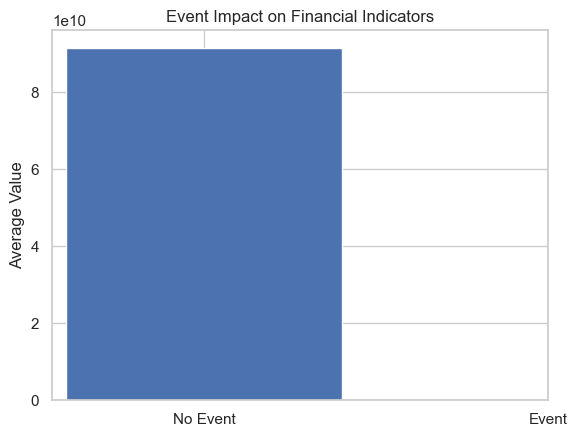

In [21]:
plt.figure()
plt.bar(impact_summary["event"], impact_summary[value_col])
plt.xticks([0, 1], ["No Event", "Event"])
plt.ylabel("Average Value")
plt.title("Event Impact on Financial Indicators")
plt.show()


In [22]:
impact_summary.to_csv(
    "../data/processed/task_3_event_impact_summary.csv",
    index=False
)

print("Task 3 output saved successfully")


Task 3 output saved successfully


In [23]:
df[["event", value_col, "year"]].head()


,event,value_numeric,year
0,0,22.0,2014.0
1,0,35.0,2017.0
2,0,46.0,2021.0
3,0,56.0,2021.0
4,0,36.0,2021.0
